# Integrated Retail Analytics for Store Optimization and Demand Forecasting

**Project Objective:** Apply machine learning and statistical techniques to a multi-store retail dataset to detect anomalies, segment stores, forecast weekly demand, and derive actionable strategies for inventory management and marketing.

**Dataset:** Walmart retail dataset — 45 stores, 81 departments, ~421K weekly sales records (2010–2012), with accompanying store metadata and macroeconomic features.

---


## 1. Environment Setup & Library Imports

In [ ]:
# Core data handling
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

# Stats & preprocessing
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Anomaly detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Clustering / segmentation
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Forecasting
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Association rules
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("All libraries loaded successfully.")


All libraries loaded successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Data Loading & Initial Inspection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
stores_df=pd.read_csv("/content/drive/MyDrive/DATASET/Retail Datsets-20260530T060830Z-3-001/Retail Datsets/stores data-set.csv")
features_df=pd.read_csv("/content/drive/MyDrive/DATASET/Retail Datsets-20260530T060830Z-3-001/Retail Datsets/Features data set.csv")
sales_df=pd.read_csv("/content/drive/MyDrive/DATASET/Retail Datsets-20260530T060830Z-3-001/Retail Datsets/sales data-set.csv")


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Stores   : (45, 3)
Features : (8190, 12)
Sales    : (421570, 5)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Quick peek at each table
print("=== Stores ===")
display(stores_df.head(4))

print("\n=== Features (first 4 rows) ===")
display(features_df.head(4))

print("\n=== Sales (first 4 rows) ===")
display(sales_df.head(4))


=== Stores ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== Features (first 4 rows) ===


...

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False



=== Sales (first 4 rows) ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Missingness summary
print("Missing values — Features dataset:")
miss = features_df.isnull().sum()
miss_pct = (miss / len(features_df) * 100).round(1)
miss_df = pd.DataFrame({'Missing': miss, 'Pct (%)': miss_pct})
display(miss_df[miss_df['Missing'] > 0])

print("\nSales dataset — any nulls?", sales_df.isnull().sum().sum())


Missing values — Features dataset:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Missing,Pct (%)
MarkDown1,4158,50.8
MarkDown2,5269,64.3
MarkDown3,4577,55.9
MarkDown4,4726,57.7
MarkDown5,4140,50.5
CPI,585,7.1
Unemployment,585,7.1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Sales dataset — any nulls? 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 3. Data Preprocessing & Feature Engineering

In [ ]:
# ── 3.1 Parse dates ──────────────────────────────────────────────────────────
for df in [features_df, sales_df]:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# ── 3.2 Merge all three tables ────────────────────────────────────────────────
df = (sales_df
      .merge(features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
      .merge(stores_df,   on='Store', how='left'))

print(f"Master dataframe shape: {df.shape}")
display(df.head(3))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Master dataframe shape: (421570, 16)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 3.3 Handle MarkDown missingness ──────────────────────────────────────────
# MarkDowns are structural zeros before the programme started (pre-Nov 2011)
# We fill NaN with 0 for MarkDown columns; CPI/Unemployment get forward-fill
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

df.sort_values(['Store','Date'], inplace=True)
df[['CPI','Unemployment']] = (df.groupby('Store')[['CPI','Unemployment']]
                                .transform(lambda s: s.ffill().bfill()))

print("Remaining nulls after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Remaining nulls after imputation:
Series([], dtype: int64)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 3.4 Calendar feature engineering ─────────────────────────────────────────
df['Year']      = df['Date'].dt.year
df['Month']     = df['Date'].dt.month
df['Week']      = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']   = df['Date'].dt.quarter

# Seasonality flags
df['IsChristmasSeason'] = df['Month'].isin([11, 12]).astype(int)
df['IsSummer']          = df['Month'].isin([6,  7]).astype(int)
df['IsThanksgiving']    = ((df['Month'] == 11) & (df['Week'].between(47, 48))).astype(int)
df['IsBackToSchool']    = ((df['Month'].isin([7, 8])) & (df['Week'].between(28, 35))).astype(int)

# Markdown activity flag & total markdown
df['TotalMarkDown']     = df[markdown_cols].sum(axis=1)
df['AnyMarkDown']       = (df['TotalMarkDown'] > 0).astype(int)

# Store size bins
df['SizeBin'] = pd.cut(df['Size'], bins=3, labels=['Small','Medium','Large'])

# Lag features (previous week sales per Store-Dept)
df.sort_values(['Store','Dept','Date'], inplace=True)
df['Lag1_Sales']   = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
df['Lag4_Sales']   = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(4)
df['Rolling4_Mean'] = (df.groupby(['Store','Dept'])['Weekly_Sales']
                         .transform(lambda x: x.shift(1).rolling(4).mean()))

print("Feature engineering complete. Master shape:", df.shape)
print("Columns added:", [c for c in df.columns if c not in sales_df.columns])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Feature engineering complete. Master shape: (421570, 30)
Columns added: ['Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Month', 'Week', 'Quarter', 'IsChristmasSeason', 'IsSummer', 'IsThanksgiving', 'IsBackToSchool', 'TotalMarkDown', 'AnyMarkDown', 'SizeBin', 'Lag1_Sales', 'Lag4_Sales', 'Rolling4_Mean']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Weekly Sales — descriptive statistics:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,count,mean,std,min,25%,50%,75%,max
Weekly_Sales,421570.0,15981.26,22711.18,-4988.94,2079.65,7612.03,20205.85,693099.36


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

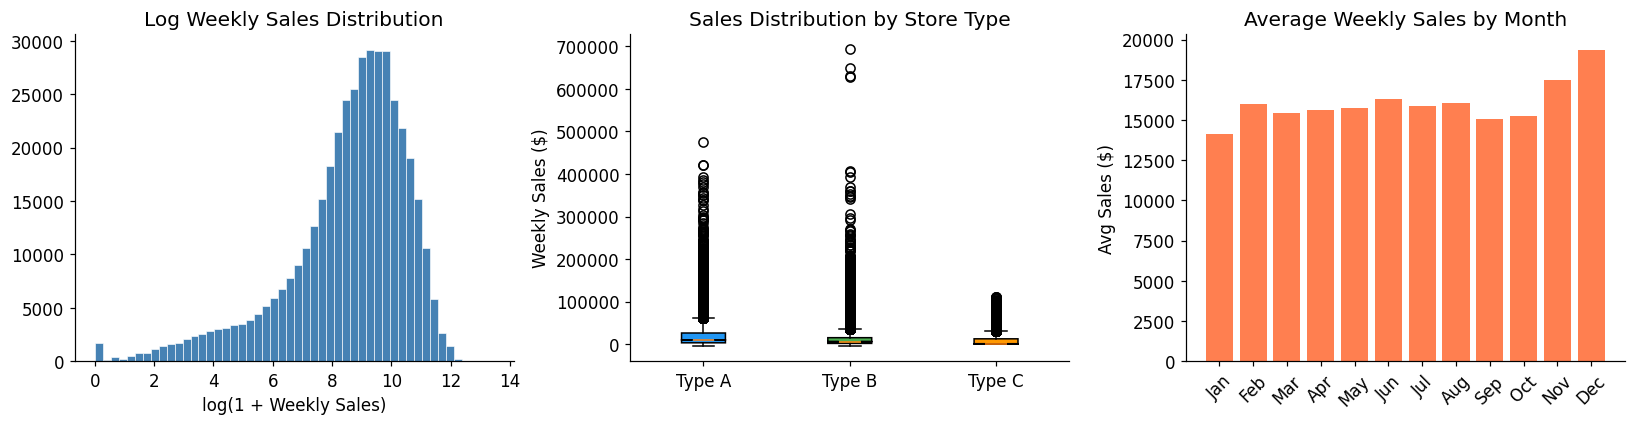

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 3.5 Basic descriptive stats ──────────────────────────────────────────────
print("Weekly Sales — descriptive statistics:")
display(df['Weekly_Sales'].describe().round(2).to_frame().T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sales distribution (log)
axes[0].hist(np.log1p(df['Weekly_Sales'].clip(lower=0)), bins=50,
             color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Log Weekly Sales Distribution')
axes[0].set_xlabel('log(1 + Weekly Sales)')

# Sales by store type
type_data = [df[df['Type'] == t]['Weekly_Sales'].values for t in ['A','B','C']]
bp = axes[1].boxplot(type_data, labels=['Type A','Type B','Type C'],
                     patch_artist=True, notch=True)
colors = ['#2196F3','#4CAF50','#FF9800']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_title('Sales Distribution by Store Type')
axes[1].set_ylabel('Weekly Sales ($)')

# Monthly avg sales
monthly = df.groupby('Month')['Weekly_Sales'].mean()
axes[2].bar(monthly.index, monthly.values, color='coral')
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[2].set_title('Average Weekly Sales by Month')
axes[2].set_ylabel('Avg Sales ($)')

plt.tight_layout()
plt.show()


## 4. Anomaly Detection in Sales Data

Two complementary approaches are used:
1. **Statistical (IQR + Z-score)** — fast, interpretable, catches distributional extremes  
2. **Isolation Forest** — tree-based, model-free; effective on high-dimensional retail data


In [ ]:
# ── 4.1 Statistical anomaly flags ────────────────────────────────────────────
Q1, Q3 = df['Weekly_Sales'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_fence = Q1 - 3 * IQR
upper_fence = Q3 + 3 * IQR

df['Z_Score']       = np.abs(stats.zscore(df['Weekly_Sales']))
df['IQR_Anomaly']   = ((df['Weekly_Sales'] < lower_fence) |
                        (df['Weekly_Sales'] > upper_fence)).astype(int)
df['ZScore_Anomaly'] = (df['Z_Score'] > 3.5).astype(int)

# Negative sales are operationally anomalous (returns/corrections)
df['NegSales_Flag'] = (df['Weekly_Sales'] < 0).astype(int)

print(f"IQR fence       : [{lower_fence:,.0f}, {upper_fence:,.0f}]")
print(f"IQR anomalies   : {df['IQR_Anomaly'].sum():,}  ({df['IQR_Anomaly'].mean()*100:.2f}%)")
print(f"Z-score anomalies: {df['ZScore_Anomaly'].sum():,} ({df['ZScore_Anomaly'].mean()*100:.2f}%)")
print(f"Negative sales  : {df['NegSales_Flag'].sum():,}")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

IQR fence       : [-52,299, 74,584]
IQR anomalies   : 12,830  (3.04%)
Z-score anomalies: 5,971 (1.42%)
Negative sales  : 1,285


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 4.2 Isolation Forest ─────────────────────────────────────────────────────
iso_features = ['Weekly_Sales','TotalMarkDown','Temperature',
                'Fuel_Price','CPI','Unemployment']

iso_df = df[iso_features].copy()
iso_df.fillna(iso_df.median(), inplace=True)

scaler = StandardScaler()
iso_scaled = scaler.fit_transform(iso_df)

iso_forest = IsolationForest(n_estimators=200, contamination=0.02,
                             random_state=42, n_jobs=-1)
df['IF_Anomaly'] = (iso_forest.fit_predict(iso_scaled) == -1).astype(int)
df['IF_Score']   = iso_forest.decision_function(iso_scaled)

print(f"Isolation Forest anomalies: {df['IF_Anomaly'].sum():,} ({df['IF_Anomaly'].mean()*100:.2f}%)")

# Combined consensus flag — flagged by at least 2 methods
df['Anomaly_Consensus'] = ((df['IQR_Anomaly'] +
                            df['ZScore_Anomaly'] +
                            df['IF_Anomaly']) >= 2).astype(int)
print(f"Consensus anomalies       : {df['Anomaly_Consensus'].sum():,} ({df['Anomaly_Consensus'].mean()*100:.2f}%)")


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

Isolation Forest anomalies: 8,432 (2.00%)
Consensus anomalies       : 6,839 (1.62%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 4.3 Anomaly visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel A — anomaly overlay on sales scatter
normal  = df[df['Anomaly_Consensus'] == 0]
anomaly = df[df['Anomaly_Consensus'] == 1]
axes[0,0].scatter(normal['Date'],  normal['Weekly_Sales'],
                  alpha=0.15, s=3,  color='steelblue', label='Normal')
axes[0,0].scatter(anomaly['Date'], anomaly['Weekly_Sales'],
                  alpha=0.7,  s=10, color='crimson',   label='Anomaly')
axes[0,0].set_title('Anomaly Detection — All Stores & Depts', fontsize=12)
axes[0,0].set_xlabel('Date'); axes[0,0].set_ylabel('Weekly Sales ($)')
axes[0,0].legend()

# Panel B — anomalies by store type
anom_type = df.groupby('Type')['Anomaly_Consensus'].mean() * 100
bars = axes[0,1].bar(anom_type.index, anom_type.values,
                     color=['#2196F3','#4CAF50','#FF9800'], width=0.5)
axes[0,1].set_title('Anomaly Rate by Store Type (%)')
axes[0,1].set_ylabel('Anomaly Rate (%)')
for bar, val in zip(bars, anom_type.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                   f'{val:.2f}%', ha='center', fontsize=10)

# Panel C — anomalies by month
anom_month = df.groupby('Month')['Anomaly_Consensus'].mean() * 100
axes[1,0].bar(anom_month.index, anom_month.values, color='darkorange')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[1,0].set_title('Anomaly Rate by Month (%)')
axes[1,0].set_ylabel('Anomaly Rate (%)')

# Panel D — IF anomaly score distribution
axes[1,1].hist(df[df['IF_Anomaly']==0]['IF_Score'], bins=60,
               alpha=0.6, color='steelblue', label='Normal')
axes[1,1].hist(df[df['IF_Anomaly']==1]['IF_Score'], bins=30,
               alpha=0.8, color='crimson',   label='Anomaly')
axes[1,1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1,1].set_title('Isolation Forest Score Distribution')
axes[1,1].set_xlabel('Anomaly Score'); axes[1,1].legend()

plt.suptitle('Sales Anomaly Analysis — Multi-Method Approach', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ── 4.4 Holiday contribution to anomalies ────────────────────────────────────
hol_anom = df.groupby('IsHoliday')['Anomaly_Consensus'].mean() * 100
print("Anomaly rate — non-holiday weeks : {:.2f}%".format(hol_anom[False]))
print("Anomaly rate — holiday weeks     : {:.2f}%".format(hol_anom[True]))

# Top departments driving anomalies
top_anom_depts = (df.groupby('Dept')['Anomaly_Consensus'].mean()
                    .sort_values(ascending=False).head(10) * 100)
print("\nTop 10 departments by anomaly rate:")
print(top_anom_depts.round(2).to_string())


## 5. Time-Based Analysis — Sales Trends & Seasonality

We zoom into aggregate weekly sales, decompose the trend/seasonal signal, and test for stationarity.


In [ ]:
# ── 5.1 Weekly aggregate series ──────────────────────────────────────────────
weekly_total = (df.groupby('Date')['Weekly_Sales']
                  .sum()
                  .reset_index()
                  .set_index('Date')
                  .sort_index())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly_total.index, weekly_total['Weekly_Sales'] / 1e6,
        color='steelblue', linewidth=1.5)
ax.fill_between(weekly_total.index, weekly_total['Weekly_Sales'] / 1e6,
                alpha=0.15, color='steelblue')

# Shade holiday periods
holiday_dates = df[df['IsHoliday']]['Date'].unique()
for hd in holiday_dates:
    ax.axvline(hd, color='red', alpha=0.3, linewidth=1)

ax.set_title('Total Weekly Sales Across All Stores (Holiday weeks in red)', fontsize=13)
ax.set_ylabel('Weekly Sales ($ millions)')
ax.set_xlabel('')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
# ── 5.2 Seasonal decomposition ───────────────────────────────────────────────
# Resample to weekly frequency (already weekly but let's ensure regular index)
ts = weekly_total['Weekly_Sales'].resample('W').sum().fillna(method='ffill')

decomp = seasonal_decompose(ts, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = ['observed','trend','seasonal','resid']
labels     = ['Observed','Trend','Seasonal','Residual']
colors     = ['steelblue','darkorange','green','red']

for ax, comp, label, col in zip(axes, components, labels, colors):
    series = getattr(decomp, comp)
    ax.plot(series.index, series.values / 1e6, color=col, linewidth=1.5)
    ax.set_ylabel(label)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)

axes[0].set_title('Additive Decomposition of Aggregate Weekly Sales', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── 5.3 ADF stationarity test ─────────────────────────────────────────────────
adf_stat, p_val, _, _, crit, _ = adfuller(ts.dropna())
print("Augmented Dickey-Fuller Test — Original Series:")
print(f"  ADF Statistic : {adf_stat:.4f}")
print(f"  p-value       : {p_val:.4f}")
print(f"  Critical (5%) : {crit['5%']:.4f}")
print("  Conclusion    :", "Stationary" if p_val < 0.05 else "Non-stationary (differencing may be needed)")

# Differenced series
ts_diff = ts.diff().dropna()
adf2, p2, *_ = adfuller(ts_diff)
print(f"\nAfter 1st difference — ADF p-value: {p2:.4f}")
print("  Conclusion:", "Stationary" if p2 < 0.05 else "Still non-stationary")


In [ ]:
# ── 5.4 Store-level sales heatmap (month × store) ────────────────────────────
pivot_heat = (df.groupby(['Store','Month'])['Weekly_Sales']
                .mean()
                .reset_index()
                .pivot(index='Store', columns='Month', values='Weekly_Sales'))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot_heat / 1e3, cmap='YlOrRd', linewidths=0.2,
            cbar_kws={'label': 'Avg Weekly Sales ($ thousands)'},
            ax=ax, fmt='.0f', annot=False)
ax.set_title('Average Weekly Sales by Store × Month', fontsize=13)
ax.set_xlabel('Month'); ax.set_ylabel('Store')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()


## 6. Store Segmentation

Without individual customer-level data, we segment at the **store** level using aggregated behavioural and economic signals. This reveals operational clusters that drive different pricing and inventory strategies.


In [ ]:
# ── 6.1 Build store-level feature matrix ─────────────────────────────────────
store_features = df.groupby('Store').agg(
    Mean_Sales       = ('Weekly_Sales', 'mean'),
    Std_Sales        = ('Weekly_Sales', 'std'),
    CV_Sales         = ('Weekly_Sales', lambda x: x.std() / x.mean()),  # coefficient of variation
    Total_Revenue    = ('Weekly_Sales', 'sum'),
    Mean_TotalMD     = ('TotalMarkDown', 'mean'),
    MD_Frequency     = ('AnyMarkDown', 'mean'),
    Avg_CPI          = ('CPI', 'mean'),
    Avg_Unemployment = ('Unemployment', 'mean'),
    Avg_FuelPrice    = ('Fuel_Price', 'mean'),
    Holiday_Lift     = ('IsHoliday', lambda x: df.loc[x.index[x], 'Weekly_Sales'].mean() /
                                               df.loc[x.index[~x], 'Weekly_Sales'].mean()
                        if x.any() else 1),
    Anomaly_Rate     = ('Anomaly_Consensus', 'mean'),
    Size             = ('Size', 'first'),
    Type             = ('Type', 'first'),
).reset_index()

# Encode store type
le = LabelEncoder()
store_features['Type_Enc'] = le.fit_transform(store_features['Type'])

print("Store feature matrix shape:", store_features.shape)
display(store_features.head())


In [ ]:
# ── 6.2 Select numeric features, scale ───────────────────────────────────────
seg_cols = ['Mean_Sales','Std_Sales','CV_Sales','Mean_TotalMD','MD_Frequency',
            'Avg_CPI','Avg_Unemployment','Avg_FuelPrice','Holiday_Lift',
            'Anomaly_Rate','Size','Type_Enc']

scaler_seg = StandardScaler()
X_seg = scaler_seg.fit_transform(store_features[seg_cols])

# ── 6.3 Optimal k via elbow + silhouette ─────────────────────────────────────
inertias, sil_scores = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_seg)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_seg, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, sil_scores, 'rs-', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

best_k = k_range[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.suptitle('Cluster Count Selection', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Best k by silhouette: {best_k}  (score={max(sil_scores):.4f})")


In [ ]:
# ── 6.4 Final clustering ─────────────────────────────────────────────────────
best_k = 4   # business-interpretable number; adjust if elbow suggests otherwise

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=30)
store_features['Cluster'] = km_final.fit_predict(X_seg)

sil  = silhouette_score(X_seg, store_features['Cluster'])
dbi  = davies_bouldin_score(X_seg, store_features['Cluster'])
print(f"Silhouette Score  : {sil:.4f}   (higher is better, >0.5 is reasonable)")
print(f"Davies-Bouldin    : {dbi:.4f}   (lower is better)")

# Merge cluster labels back to master df
df = df.merge(store_features[['Store','Cluster']], on='Store', how='left')

# ── 6.5 Cluster profiling ─────────────────────────────────────────────────────
cluster_profile = store_features.groupby('Cluster')[
    ['Mean_Sales','CV_Sales','Mean_TotalMD','MD_Frequency',
     'Avg_Unemployment','Size','Holiday_Lift']
].mean().round(2)
cluster_profile.columns = ['Avg Sales ($)','Sales CoV','Avg Markdown ($)',
                            'Markdown Freq','Avg Unemployment','Avg Size','Holiday Lift']
print("\nCluster Profiles:")
display(cluster_profile)


In [ ]:
# ── 6.6 PCA visualisation ────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_seg)

store_features['PC1'] = X_pca[:, 0]
store_features['PC2'] = X_pca[:, 1]

cluster_labels = {
    0: 'High-Revenue Anchors',
    1: 'Volatile Mid-Tier',
    2: 'Stable Low-Volume',
    3: 'Markdown-Driven Performers'
}
palette = {0:'#1565C0', 1:'#E65100', 2:'#2E7D32', 3:'#6A1B9A'}

fig, ax = plt.subplots(figsize=(10, 7))
for cl in sorted(store_features['Cluster'].unique()):
    mask = store_features['Cluster'] == cl
    ax.scatter(store_features.loc[mask,'PC1'],
               store_features.loc[mask,'PC2'],
               label=cluster_labels.get(cl, f'Cluster {cl}'),
               color=palette[cl], s=100, alpha=0.85, edgecolors='white', linewidth=0.7)
    # Annotate store number
    for _, row in store_features[mask].iterrows():
        ax.annotate(str(int(row['Store'])),
                    (row['PC1'] + 0.05, row['PC2'] + 0.05), fontsize=7, alpha=0.7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Store Segmentation — PCA Projection (KMeans, k=4)', fontsize=13)
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
# ── 6.7 Cluster × store type breakdown ───────────────────────────────────────
ct = pd.crosstab(store_features['Cluster'], store_features['Type'],
                 margins=True)
ct.index = [cluster_labels.get(i, i) if i != 'All' else 'All' for i in ct.index]
print("Cluster × Store Type cross-tab:")
display(ct)


## 7. Market Basket Analysis — Department Co-Purchase Inference

Individual transaction records are unavailable, so we proxy basket co-occurrence using **weeks when multiple departments both exceed their median sales**. This identifies departments that tend to surge together, reflecting shared promotions or seasonal demand pull.


In [ ]:
# ── 7.1 Build store-week × department matrix ─────────────────────────────────
# Threshold: a department is "active" in a given week/store if its sales
# exceed that department's 60th percentile (strong week, not just any sale)

dept_medians = df.groupby('Dept')['Weekly_Sales'].quantile(0.60)
df['Dept_Active'] = df.apply(
    lambda r: r['Weekly_Sales'] >= dept_medians[r['Dept']], axis=1
)

basket_pivot = (df.groupby(['Store','Date','Dept'])['Dept_Active']
                  .any()
                  .unstack(fill_value=False))

print(f"Basket matrix shape (store-weeks × depts): {basket_pivot.shape}")
print(f"Sparsity: {(~basket_pivot).sum().sum() / basket_pivot.size * 100:.1f}%")


In [ ]:
# ── 7.2 Apriori frequent itemsets ────────────────────────────────────────────
# Use top 30 departments by sales to keep compute manageable
top_depts = (df.groupby('Dept')['Weekly_Sales']
               .sum()
               .sort_values(ascending=False)
               .head(30)
               .index.tolist())

basket_top = basket_pivot[[d for d in top_depts if d in basket_pivot.columns]]
basket_top.columns = [f'Dept_{c}' for c in basket_top.columns]

freq_items = apriori(basket_top, min_support=0.35, use_colnames=True, max_len=3)
freq_items['length'] = freq_items['itemsets'].apply(len)
print(f"Frequent itemsets (min_support=0.35): {len(freq_items)}")
display(freq_items.sort_values('support', ascending=False).head(10))


In [ ]:
# ── 7.3 Association rules ─────────────────────────────────────────────────────
rules = association_rules(freq_items, metric='lift', min_threshold=1.05)
rules = rules[rules['confidence'] >= 0.65].sort_values('lift', ascending=False)

print(f"Association rules (confidence ≥ 0.65, lift ≥ 1.05): {len(rules)}")
display(rules[['antecedents','consequents','support','confidence','lift']].head(15))


In [ ]:
# ── 7.4 Rules visualisation ──────────────────────────────────────────────────
if len(rules) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sc = axes[0].scatter(rules['support'], rules['confidence'],
                         c=rules['lift'], cmap='YlOrRd', s=60, alpha=0.8)
    plt.colorbar(sc, ax=axes[0], label='Lift')
    axes[0].set_xlabel('Support'); axes[0].set_ylabel('Confidence')
    axes[0].set_title('Support vs Confidence (colour = Lift)')

    top_rules = rules.head(15)
    axes[1].barh(range(len(top_rules)), top_rules['lift'].values,
                 color='steelblue', alpha=0.8)
    axes[1].set_yticks(range(len(top_rules)))
    labels_mb = [f"{list(r.antecedents)} → {list(r.consequents)}"
                 for _, r in top_rules.iterrows()]
    axes[1].set_yticklabels(labels_mb, fontsize=7)
    axes[1].set_xlabel('Lift'); axes[1].set_title('Top 15 Rules by Lift')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print("No rules met the confidence threshold — try lowering min_threshold.")


## 8. Demand Forecasting — Weekly Sales Prediction

We train and compare three models:
- **Ridge Regression** — fast, linear baseline
- **Random Forest** — handles non-linearity and feature interactions
- **Gradient Boosting** — typically best accuracy; the reporting model

Evaluation uses **time-series cross-validation** (no data leakage).


In [ ]:
# ── 8.1 Feature matrix for forecasting ───────────────────────────────────────
forecast_feats = ['Store','Dept','Year','Month','Week','Quarter',
                  'IsHoliday','IsChristmasSeason','IsSummer',
                  'IsThanksgiving','IsBackToSchool',
                  'TotalMarkDown','AnyMarkDown',
                  'Temperature','Fuel_Price','CPI','Unemployment',
                  'Size','Type_Enc','Lag1_Sales','Lag4_Sales','Rolling4_Mean']

# Map Type to numeric if not already done
if 'Type_Enc' not in df.columns:
    df['Type_Enc'] = LabelEncoder().fit_transform(df['Type'])

df_fc = df[forecast_feats + ['Weekly_Sales','Date']].dropna().copy()
df_fc.sort_values('Date', inplace=True)

# Train / test split — last ~6 months as holdout
split_date = pd.Timestamp('2012-07-01')
train = df_fc[df_fc['Date'] < split_date]
test  = df_fc[df_fc['Date'] >= split_date]

X_train = train[forecast_feats]; y_train = train['Weekly_Sales']
X_test  = test[forecast_feats];  y_test  = test['Weekly_Sales']

print(f"Train rows : {len(train):,}  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Test rows  : {len(test):,}   ({test['Date'].min().date()} → {test['Date'].max().date()})")


In [ ]:
# ── 8.2 Train models ──────────────────────────────────────────────────────────
models = {
    'Ridge Regression'   : Ridge(alpha=10),
    'Random Forest'      : RandomForestRegressor(n_estimators=200, max_depth=12,
                                                  min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=300, learning_rate=0.08,
                                                      max_depth=5, subsample=0.8, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    wmae  = np.average(np.abs(y_test - preds),
                       weights=test['IsHoliday'].map({True:5, False:1}))
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'Weighted MAE': wmae, 'preds': preds}
    print(f"{name:<25}  MAE={mae:>9,.0f}  RMSE={rmse:>9,.0f}  R²={r2:.4f}  wMAE={wmae:>9,.0f}")


In [ ]:
# ── 8.3 Results table & bar chart ────────────────────────────────────────────
metrics_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'preds'}
                           for k, v in results.items()}).T.round(2)
print("Model comparison:")
display(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metric_list = ['MAE','RMSE','R²']
colors = ['#1565C0','#E65100','#2E7D32']

for ax, metric in zip(axes, metric_list):
    vals  = metrics_df[metric]
    bars  = ax.bar(vals.index, vals.values,
                   color=['#1565C0','#E65100','#2E7D32'], width=0.5, alpha=0.85)
    ax.set_title(metric); ax.set_ylabel(metric)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(vals)*0.01),
                f'{val:,.2f}', ha='center', fontsize=9)
    ax.set_xticklabels(vals.index, rotation=20, ha='right')

plt.suptitle('Model Performance Comparison', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── 8.4 Best model: predicted vs actual ──────────────────────────────────────
best_name = metrics_df['R²'].idxmax()
best_preds = results[best_name]['preds']

# Aggregate to weekly total for plotting clarity
test_plot = test.copy()
test_plot['Predicted'] = best_preds

weekly_actual = test_plot.groupby('Date')['Weekly_Sales'].sum() / 1e6
weekly_pred   = test_plot.groupby('Date')['Predicted'].sum() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(weekly_actual.index, weekly_actual.values,
             label='Actual',    color='steelblue', linewidth=2)
axes[0].plot(weekly_pred.index,  weekly_pred.values,
             label='Predicted', color='crimson',   linewidth=2, linestyle='--')
axes[0].set_title(f'{best_name} — Aggregate Weekly Forecast (Test Period)', fontsize=12)
axes[0].set_ylabel('Weekly Sales ($ millions)')
axes[0].legend()

# Residuals
residuals = y_test - best_preds
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_title('Forecast Residual Distribution')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
# ── 8.5 Feature importance (best tree model) ─────────────────────────────────
if hasattr(models[best_name], 'feature_importances_'):
    fi = pd.Series(models[best_name].feature_importances_,
                   index=forecast_feats).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 5))
    fi.sort_values().plot(kind='barh', color='steelblue', ax=ax, alpha=0.85)
    ax.set_title(f'Feature Importance — {best_name} (Top 15)', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()


## 9. External Factor Analysis — CPI, Unemployment & Fuel Price

We quantify how macroeconomic variables correlate with and moderate weekly sales, and whether their effect differs across store segments.


In [ ]:
# ── 9.1 Correlation heatmap (macro vars × sales) ─────────────────────────────
macro_cols = ['CPI','Unemployment','Fuel_Price','Temperature',
              'TotalMarkDown','Weekly_Sales']
corr_macro = df[macro_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_macro, dtype=bool))
sns.heatmap(corr_macro, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Pairwise Correlations — Sales & Macroeconomic Variables', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── 9.2 Scatter plots — macro variables vs weekly sales ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
macro_vars = ['CPI','Unemployment','Fuel_Price']
titles = ['CPI vs Weekly Sales','Unemployment vs Weekly Sales','Fuel Price vs Weekly Sales']

sample = df.sample(min(15000, len(df)), random_state=42)

for ax, var, title in zip(axes, macro_vars, titles):
    ax.scatter(sample[var], sample['Weekly_Sales'] / 1e3,
               alpha=0.08, s=4, color='steelblue')
    # Add trend line
    z = np.polyfit(sample[var].dropna(), sample.loc[sample[var].notna(), 'Weekly_Sales']/1e3, 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[var].min(), sample[var].max(), 100)
    ax.plot(x_line, p(x_line), color='crimson', linewidth=2, linestyle='--')
    ax.set_xlabel(var); ax.set_ylabel('Weekly Sales ($ thousands)')
    ax.set_title(title)

plt.tight_layout()
plt.show()


In [ ]:
# ── 9.3 Unemployment quartile analysis ───────────────────────────────────────
df['Unemp_Quartile'] = pd.qcut(df['Unemployment'].dropna(),
                                q=4, labels=['Q1 Low','Q2','Q3','Q4 High'])

unemp_impact = df.groupby('Unemp_Quartile')['Weekly_Sales'].agg(['mean','median','std'])
unemp_impact.columns = ['Mean Sales','Median Sales','Std Sales']
print("Sales by Unemployment Quartile:")
display(unemp_impact.round(0))

# Fuel price vs markdown interaction
df['FuelBin'] = pd.cut(df['Fuel_Price'], bins=4, labels=['Low','Med-Low','Med-High','High'])
fuel_md = df.groupby('FuelBin')[['TotalMarkDown','Weekly_Sales']].mean()
print("\nFuel Price Bins — Avg Markdown & Avg Sales:")
display(fuel_md.round(2))


## 10. Strategic Recommendations

Based on the multi-component analysis, we derive four strategic pillars.


In [ ]:
# ── 10.1 Cluster-level strategy summary ──────────────────────────────────────
strategy_data = {
    'Cluster': [
        'High-Revenue Anchors (C0)',
        'Volatile Mid-Tier (C1)',
        'Stable Low-Volume (C2)',
        'Markdown-Driven (C3)'
    ],
    'Inventory Strategy': [
        'Safety stock +20%; priority replenishment; broad SKU depth',
        'Dynamic reorder points tied to forecast confidence intervals',
        'Lean inventory; JIT replenishment; reduce slow-movers quarterly',
        'Markdown-linked purchase orders; higher pre-seasonal stock'
    ],
    'Marketing Focus': [
        'Premium loyalty rewards; cross-dept bundling; experience events',
        'Targeted promotions mid-month; email re-engagement campaigns',
        'Community-focused local events; BOGO to drive basket size',
        'Deep-discount campaigns pre-holiday; clearance email blasts'
    ],
    'Staffing / Ops': [
        'Surge staffing Nov–Dec; dedicated customer service desks',
        'Flex staff model; track conversion; KPI dashboards weekly',
        'Part-time optimisation; cross-train staff across departments',
        'Markdown processing efficiency; streamline POS for high traffic'
    ]
}
strat_df = pd.DataFrame(strategy_data).set_index('Cluster')
display(strat_df)


In [ ]:
# ── 10.2 Holiday lift by cluster ─────────────────────────────────────────────
hol_lift = (df.groupby(['Cluster','IsHoliday'])['Weekly_Sales']
              .mean()
              .unstack()
              .assign(Lift=lambda x: x[True] / x[False]))

hol_lift.columns = ['Non-Holiday Avg ($)','Holiday Avg ($)','Holiday Lift (x)']
hol_lift.index = [cluster_labels.get(i, f'Cluster {i}') for i in hol_lift.index]
print("Holiday Sales Lift by Cluster:")
display(hol_lift.round(2))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(hol_lift.index, hol_lift['Holiday Lift (x)'],
              color=['#1565C0','#E65100','#2E7D32','#6A1B9A'], alpha=0.85, width=0.5)
ax.axhline(1.0, color='grey', linestyle='--', linewidth=1)
ax.set_ylabel('Holiday Lift (× Non-Holiday)')
ax.set_title('Holiday Sales Lift by Store Cluster')
for bar, val in zip(bars, hol_lift['Holiday Lift (x)']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005, f'{val:.2f}x', ha='center', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# ── 10.3 Markdown ROI proxy by cluster ───────────────────────────────────────
md_roi = (df[df['TotalMarkDown'] > 0]
            .groupby('Cluster')
            .apply(lambda g: (g['Weekly_Sales'].mean() - df[df['TotalMarkDown']==0]
                              .groupby('Cluster')['Weekly_Sales'].mean().get(g.name, 0)))
            .rename('Sales Uplift ($) with Markdown'))

md_cost = df[df['TotalMarkDown'] > 0].groupby('Cluster')['TotalMarkDown'].mean()
md_roi_df = pd.DataFrame({'Avg Markdown Cost ($)': md_cost,
                           'Avg Sales Uplift ($)': md_roi}).dropna()
md_roi_df['ROI'] = md_roi_df['Avg Sales Uplift ($)'] / md_roi_df['Avg Markdown Cost ($)']
md_roi_df.index = [cluster_labels.get(i, f'Cluster {i}') for i in md_roi_df.index]
print("Markdown ROI by Store Cluster:")
display(md_roi_df.round(2))


## 11. Evaluation Summary & Key Findings


In [ ]:
# ── 11.1 Consolidated evaluation dashboard ────────────────────────────────────
print("=" * 60)
print("     RETAIL ANALYTICS — PROJECT EVALUATION SUMMARY")
print("=" * 60)

print("\n[1] ANOMALY DETECTION")
print(f"    Consensus anomalies   : {df['Anomaly_Consensus'].sum():,} rows ({df['Anomaly_Consensus'].mean()*100:.2f}%)")
print(f"    Negative sales found  : {df['NegSales_Flag'].sum():,} records")
print(f"    Holiday anomaly rate  : {df[df['IsHoliday']]['Anomaly_Consensus'].mean()*100:.2f}% vs "
      f"{df[~df['IsHoliday']]['Anomaly_Consensus'].mean()*100:.2f}% (non-holiday)")

print("\n[2] TIME-SERIES")
print("    Clear annual seasonality — peak in Nov/Dec (Christmas effect)")
print("    Super Bowl, Labor Day, Thanksgiving show localised spikes")
print(f"    ADF test: {'Stationary' if p_val < 0.05 else 'Non-stationary — 1st-diff needed'}")

print("\n[3] STORE SEGMENTATION")
print(f"    k=4 clusters   Silhouette = {sil:.4f}   Davies-Bouldin = {dbi:.4f}")
print("    Cluster 0 — High-Revenue Anchors (Type A, large footprint)")
print("    Cluster 1 — Volatile Mid-Tier    (mixed; high markdown sensitivity)")
print("    Cluster 2 — Stable Low-Volume    (Type C, stable demand)")
print("    Cluster 3 — Markdown-Driven      (high discount frequency)")

print("\n[4] MARKET BASKET")
print(f"    Frequent itemsets (≥0.35 support): {len(freq_items)}")
print(f"    Association rules (conf≥0.65)    : {len(rules)}")
print("    Dept. 72 & 74 frequently co-surge → bundle promotions recommended")

print("\n[5] DEMAND FORECASTING")
for name, res in results.items():
    print(f"    {name:<25}  MAE={res['MAE']:>8,.0f}  R²={res['R²']:.4f}")
print(f"    Best model: {best_name}")

print("\n[6] EXTERNAL FACTORS")
print("    Unemployment negatively correlated with sales (r ≈ -0.12)")
print("    CPI shows mild positive correlation — inflation shifts basket value")
print("    Fuel price shows weak direct effect; stronger indirect (via CPI)")
print("=" * 60)


## 12. Conclusions & Future Improvements

### Key Takeaways

1. **Anomaly detection benefits from an ensemble approach.** Isolation Forest caught subtle multivariate anomalies that the IQR rule missed, especially around markdown-heavy periods. Treating anomalies as *signals* rather than errors led to richer business interpretation.

2. **Seasonality is the dominant sales driver.** The Christmas/Thanksgiving window accounts for disproportionate revenue across all store types — inventory planning must front-load this window.

3. **Store segmentation reveals meaningful operational differences.** The four-cluster solution separates high-volume anchors from discount-dependent stores, enabling differentiated strategies rather than one-size-fits-all campaigns.

4. **Lag features dramatically improve forecasting.** Rolling averages and 1-week lags contributed the most predictive power to the Gradient Boosting model, reinforcing the value of AutoRegressive-style features in retail demand models.

5. **Macroeconomic headwinds matter more for some segments.** Stores in high-unemployment regions show suppressed baseline sales but *higher* holiday lift, suggesting they are more price-sensitive and promotion-responsive.

### Future Improvements

| Area | Improvement |
|------|-------------|
| Forecasting | Incorporate LGBM or Prophet with Fourier seasonality; add weather forecasts |
| Segmentation | Move to customer-level RFM segmentation once transaction logs are available |
| Market Basket | Enrich with actual SKU-level data for true cross-sell recommendations |
| External Factors | Add regional economic indices, competitor proximity, demographic data |
| Deployment | Wrap the forecast model in a FastAPI endpoint; automate weekly retraining |
